# Visualización de Datos — Sesión completa

Este notebook está pensado como material de clase (3h40 aprox.) y como plantilla de práctica.

Reglas del juego:
- Vamos a separar **qué pregunta** queremos responder de **qué gráfico** elegimos.
- Primero haremos **Matplotlib** (control fino) y luego **Seaborn** (alto nivel y rápido).
- Cada concepto tiene: explicación corta → ejemplo → ejercicio (sin resolver).

Datasets: usaremos datasets incluidos en `seaborn` para no depender de ficheros externos (`tips`, `penguins`, `flights`, `diamonds`).

Esta versión está adaptada para una sesión de clase:
- En directo: 1 ejercicio por bloque (el resto queda para casa).
- Los apartados del **Apéndice** son opcionales.


## 0. Setup

Configuración base:
- Importaciones
- Carga de datasets
- Ajustes globales de estilo

Nota: `matplotlib` controla el lienzo (figura/ejes). `seaborn` usa matplotlib por debajo y añade defaults más agradables y funciones de alto nivel.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

# Global style (you can tweak later)
sns.set_theme(context='notebook', style='whitegrid')

def _make_synthetic_tips(n=244, seed=7):
    rng = np.random.default_rng(seed)
    days = np.array(['Thur','Fri','Sat','Sun'])
    times = np.array(['Lunch','Dinner'])
    sex = np.array(['Male','Female'])
    smoker = np.array(['Yes','No'])
    size = rng.integers(1, 6, size=n)

    time = rng.choice(times, size=n, p=[0.35, 0.65])
    day = rng.choice(days, size=n, p=[0.25, 0.15, 0.30, 0.30])
    sx = rng.choice(sex, size=n, p=[0.64, 0.36])
    sm = rng.choice(smoker, size=n, p=[0.38, 0.62])

    # total_bill depends on party size + dinner
    base = rng.gamma(shape=5, scale=4, size=n)  # ~20
    total_bill = base + (size-2)*3 + (time=='Dinner')*5
    total_bill = np.clip(total_bill, 3, None)

    # tip roughly proportional to bill + noise
    tip = total_bill * rng.normal(0.15, 0.03, size=n) + rng.normal(0.3, 0.4, size=n)
    tip = np.clip(tip, 0.5, None)

    return pd.DataFrame({
        'total_bill': total_bill.round(2),
        'tip': tip.round(2),
        'sex': sx,
        'smoker': sm,
        'day': day,
        'time': time,
        'size': size
    })

def _make_synthetic_penguins(n=333, seed=11):
    rng = np.random.default_rng(seed)
    species = np.array(['Adelie','Chinstrap','Gentoo'])
    island = np.array(['Torgersen','Biscoe','Dream'])
    sex = np.array(['Male','Female'])

    sp = rng.choice(species, size=n, p=[0.45, 0.20, 0.35])
    isl = rng.choice(island, size=n, p=[0.15, 0.55, 0.30])
    sx = rng.choice(sex, size=n, p=[0.52, 0.48])

    # Generate numeric features with species-specific centers
    centers = {
        'Adelie':     (38.8, 18.3, 190.0, 3700.0),
        'Chinstrap':  (48.8, 18.4, 196.0, 3730.0),
        'Gentoo':     (47.5, 15.0, 217.0, 5070.0),
    }
    bl, bd, fl, bm = [], [], [], []
    for s in sp:
        c = centers[s]
        bl.append(rng.normal(c[0], 2.5))
        bd.append(rng.normal(c[1], 1.2))
        fl.append(rng.normal(c[2], 6.0))
        bm.append(rng.normal(c[3], 450.0))

    return pd.DataFrame({
        'species': sp,
        'island': isl,
        'sex': sx,
        'bill_length_mm': np.array(bl),
        'bill_depth_mm': np.array(bd),
        'flipper_length_mm': np.array(fl),
        'body_mass_g': np.array(bm),
    })

def _make_synthetic_flights(start_year=1949, end_year=1960, seed=13):
    rng = np.random.default_rng(seed)
    months = [calendar.month_abbr[i] for i in range(1,13)]
    rows = []
    level = 110
    for y in range(start_year, end_year+1):
        for m_i, m in enumerate(months, start=1):
            # trend + seasonality + noise
            trend = (y - start_year) * 18
            season = 35*np.sin((m_i-1)/12*2*np.pi - 0.5) + 50
            passengers = level + trend + season + rng.normal(0, 10)
            rows.append((y, m, max(50, int(round(passengers)))))
    return pd.DataFrame(rows, columns=['year','month','passengers'])

def _make_synthetic_diamonds(n=53940, seed=17):
    rng = np.random.default_rng(seed)
    cut = rng.choice(['Fair','Good','Very Good','Premium','Ideal'], size=n, p=[0.03,0.09,0.22,0.26,0.40])
    color = rng.choice(list('DEFGHIJ'), size=n, p=[0.13,0.18,0.16,0.15,0.13,0.11,0.14])
    clarity = rng.choice(['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'], size=n,
                         p=[0.01,0.17,0.24,0.23,0.15,0.10,0.07,0.03])
    carat = np.clip(rng.gamma(2.0, 0.35, size=n), 0.2, 3.5)
    price = (carat**1.7)*3500 + rng.normal(0, 500, size=n)
    price = np.clip(price, 326, None).astype(int)
    return pd.DataFrame({'carat':carat,'cut':cut,'color':color,'clarity':clarity,'price':price})

# Try seaborn sample datasets; if unavailable (no internet), fall back to synthetic data.
try:
    tips = sns.load_dataset('tips')
    penguins = sns.load_dataset('penguins')
    flights = sns.load_dataset('flights')
    diamonds = sns.load_dataset('diamonds')
    _data_src = "seaborn sample datasets"
except Exception as e:
    tips = _make_synthetic_tips()
    penguins = _make_synthetic_penguins()
    flights = _make_synthetic_flights()
    diamonds = _make_synthetic_diamonds(n=10000)
    _data_src = "synthetic fallback (no internet for sns.load_dataset)"

print("Data source:", _data_src)
print('tips:', tips.shape, '| penguins:', penguins.shape, '| flights:', flights.shape, '| diamonds:', diamonds.shape)
display(tips.head())


Data source: seaborn sample datasets
tips: (244, 7) | penguins: (344, 7) | flights: (144, 3) | diamonds: (53940, 10)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


---
## 1) Qué significa “visualizar bien”

Visualizar sirve para:
- **Explorar**: detectar patrones/anomalías que una tabla oculta.
- **Validar**: descubrir errores (outliers imposibles, mezclas de unidades, categorías mal codificadas).
- **Comunicar**: hacer que alguien entienda una idea en 10 segundos.

Traducción a decisiones:
- Comparar categorías → barras
- Ver distribución → histograma / boxplot / violin
- Ver relación → scatter / regplot
- Ver evolución temporal → líneas
- Ver matriz categoría×categoría → heatmap


### Ejercicio 0 (rápido)

Para cada pregunta, escribe qué gráfico usarías y por qué (1 frase):
1) ¿Quién deja más propina: fumadores o no fumadores?
2) ¿Hay relación entre cuenta total y propina?
3) ¿Cómo evoluciona el número de pasajeros con el tiempo?
4) ¿Qué combinación mes-año tiene más pasajeros?


**Respuestas (1 frase cada una):**
1) **Boxplot/violin** de `tip` por `smoker` para comparar distribuciones (mediana y dispersión).
2) **Scatter/regplot** `total_bill` vs `tip` para ver relación y posible tendencia.
3) **Barplot** de `tip` media por `day` (y si hace falta, con intervalos de confianza) para comparar días.


---
## 2) Matplotlib vs Seaborn (diferencias prácticas)

**Matplotlib**:
- Más bajo nivel
- Máximo control (tamaño, ejes, anotaciones, estilos finos)
- Ideal para figuras “finales” o layouts complejos

**Seaborn**:
- Alto nivel
- Menos líneas de código
- Integración con DataFrames y estadísticas (medias, intervalos, etc.)

Regla útil:
- Explorar rápido → Seaborn
- Publicar/presentar con control → Matplotlib (a veces combinado con Seaborn)

---
## 3) Matplotlib básico: Figura, Ejes, títulos, labels y leyenda

Dos estilos de uso:
1) `plt.<func>` (rápido)
2) `fig, ax = plt.subplots()` (recomendado para control)

Conceptos:
- **Figure**: el lienzo completo
- **Axes**: el área donde se dibuja un gráfico


### Ejemplo 3.1 (API de `ax` recomendada)
Vamos a dibujar un histograma simple con control de título y etiquetas.

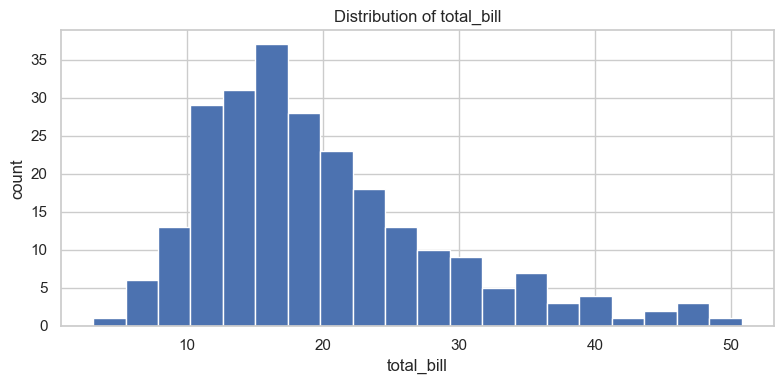

In [31]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(tips['total_bill'], bins=20, edgecolor='white')
ax.set_title('Distribution of total_bill')
ax.set_xlabel('total_bill')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

### Ejercicio 1

Crea un histograma de `tip` con:
- 25 bins
- título
- labels de ejes
- `tight_layout()`


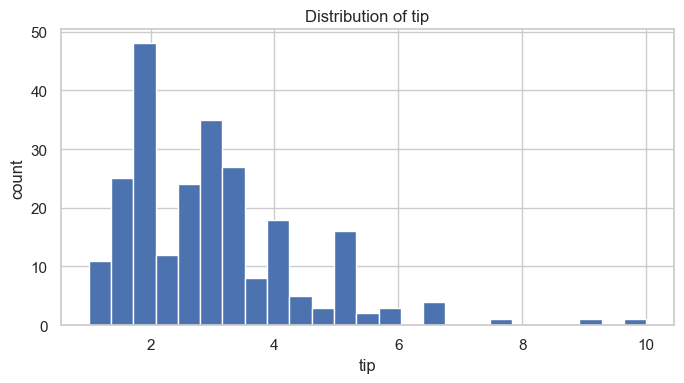

In [32]:
# Exercise 1
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(tips['tip'], bins=25, edgecolor='white')
ax.set_title('Distribution of tip')
ax.set_xlabel('tip')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


---
## 4) Configuración y estilo: tamaño, tipografías, rotación, grid

En clase y en empresa, lo que más se agradece:
- tamaño legible
- título y ejes claros
- ticks no solapados
- grid suave (si ayuda)

Herramientas:
- `figsize`
- `ax.tick_params(...)`
- `plt.xticks(rotation=...)`
- `rcParams` (configuración global)
- `sns.set_theme(context=..., style=...)`


### Ejemplo 4.1 (rcParams + rotación)
Configuramos tamaños globales (solo para esta sesión) y dibujamos una barra horizontal.

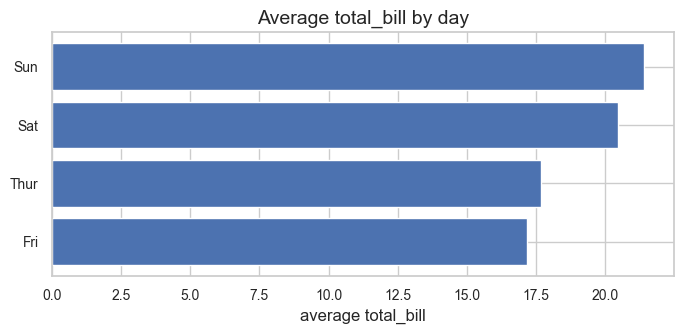

In [33]:
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

day_mean = tips.groupby('day', as_index=False)['total_bill'].mean().sort_values('total_bill')

fig, ax = plt.subplots(figsize=(7,3.5))
ax.barh(day_mean['day'], day_mean['total_bill'])
ax.set_title('Average total_bill by day')
ax.set_xlabel('average total_bill')
plt.tight_layout()
plt.show()

### Ejercicio 2

Crea un barplot horizontal con la **propina media** por `day` y ajusta:
- `figsize`
- `titlesize` y `labelsize` (puede ser global con rcParams o local con set_title/set_xlabel)


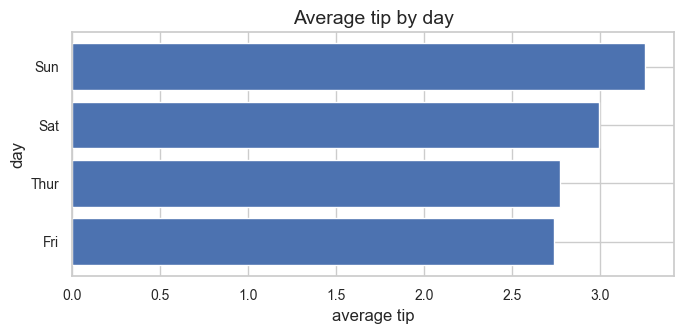

In [34]:
# Exercise 2
# Average tip by day (horizontal barplot)
day_tip_mean = tips.groupby('day', as_index=False)['tip'].mean().sort_values('tip')

fig, ax = plt.subplots(figsize=(7,3.5))
ax.barh(day_tip_mean['day'], day_tip_mean['tip'])
ax.set_title('Average tip by day', fontsize=14)
ax.set_xlabel('average tip', fontsize=12)
ax.set_ylabel('day', fontsize=12)
plt.tight_layout()
plt.show()


---
## 5) Comparación categórica (Seaborn): barplot, order, hue, error bars

Seaborn `barplot`:
- Por defecto dibuja la **media** de `y` por cada categoría en `x`.
- Puede añadir intervalos (según versión) automáticamente.

Cosas que importan en la práctica:
- Ordenar categorías (`order=`)
- Comparar subgrupos con `hue=`
- Elegir paleta (`palette=`)


### Ejemplo 5.1 (barplot con orden)
Ordenamos por media de total_bill y pintamos.

/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/1044445076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', order=order_days, palette='Set2')


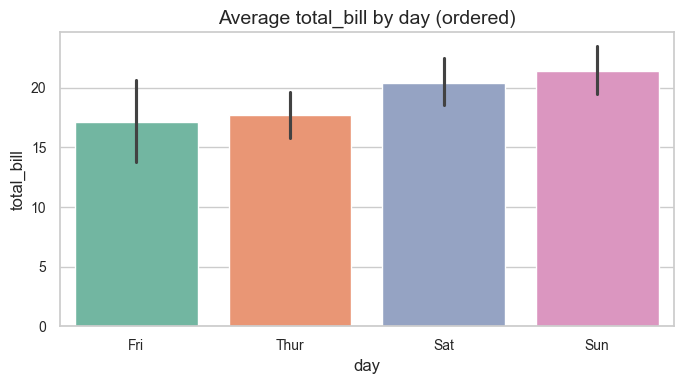

In [35]:
order_days = tips.groupby('day')['total_bill'].mean().sort_values().index

plt.figure(figsize=(7,4))
sns.barplot(data=tips, x='day', y='total_bill', order=order_days, palette='Set2')
plt.title('Average total_bill by day (ordered)')
plt.tight_layout()
plt.show()

### Ejemplo 5.2 (barplot con hue)
Comparación por turno (`time`).

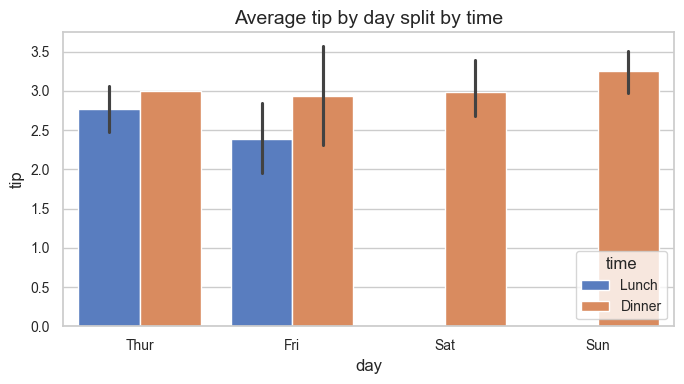

In [36]:
plt.figure(figsize=(7,4))
sns.barplot(data=tips, x='day', y='tip', hue='time', palette='muted')
plt.title('Average tip by day split by time')
plt.tight_layout()
plt.show()

### Ejercicio 3

1) Barplot: `tip` media por `day`, separado por `smoker` (`hue`).
2) Ordena los días por propina media total.
3) Prueba 2 paletas distintas (`Set2`, `viridis`, `coolwarm`, etc.).

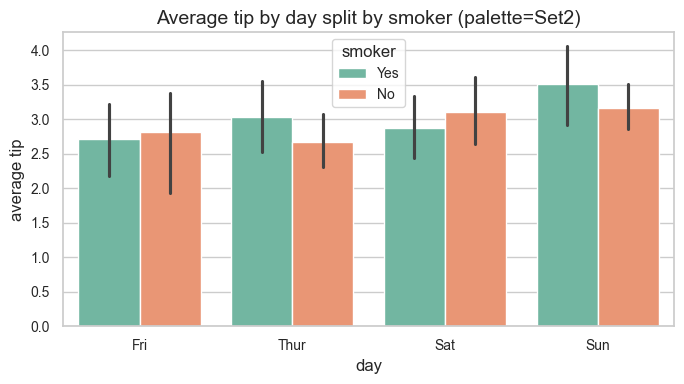

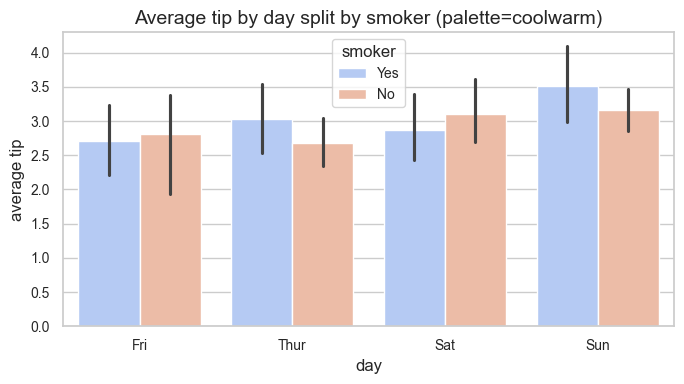

In [37]:
# Exercise 3
# Order days by overall mean tip
order_days = (tips.groupby('day')['tip'].mean().sort_values()).index.tolist()

for pal in ['Set2', 'coolwarm']:
    plt.figure(figsize=(7,4))
    sns.barplot(
        data=tips,
        x='day',
        y='tip',
        hue='smoker',
        order=order_days,
        palette=pal
    )
    plt.title(f'Average tip by day split by smoker (palette={pal})')
    plt.xlabel('day')
    plt.ylabel('average tip')
    plt.tight_layout()
    plt.show()


---
## 6) Distribuciones: histplot, kde, boxplot, violinplot

Objetivo:
- entender forma (sesgo, colas)
- comparar distribuciones por grupo

Cuándo usar:
- Histograma/KDE: forma general
- Boxplot: resumen robusto (mediana, IQR, outliers)
- Violin: forma + densidad, útil si hay bastantes datos

### Ejemplo 6.1 (hist + KDE)
Distribución de `tip`.

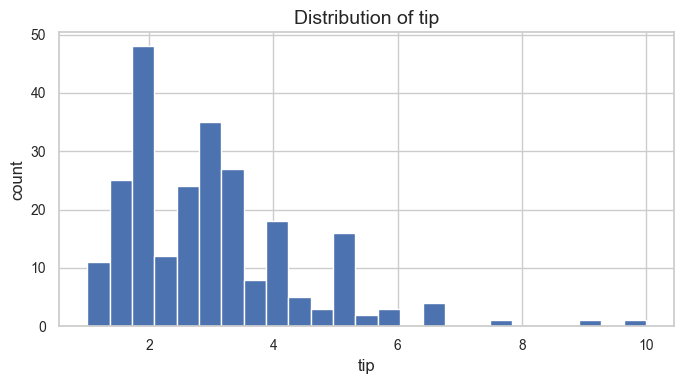

In [38]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(tips['tip'], bins=25, edgecolor='white')
ax.set_title('Distribution of tip')
ax.set_xlabel('tip')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


### Ejemplo 6.2 (boxplot por grupo)
Propina por día.

/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/3514656400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='tip', palette='pastel')


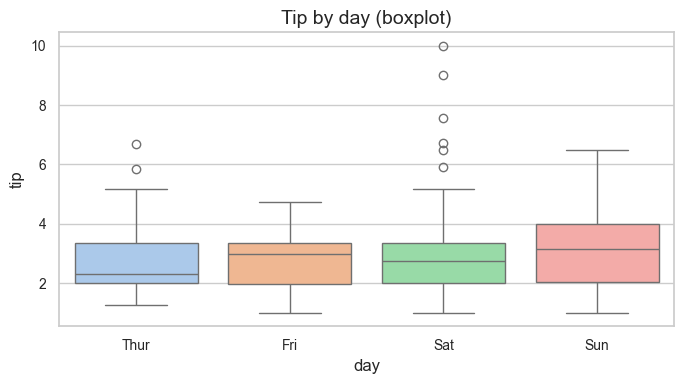

In [39]:
plt.figure(figsize=(7,4))
sns.boxplot(data=tips, x='day', y='tip', palette='pastel')
plt.title('Tip by day (boxplot)')
plt.tight_layout()
plt.show()

### Ejemplo 6.3 (violin + split por hue)
Total de cuenta por turno y fumador.

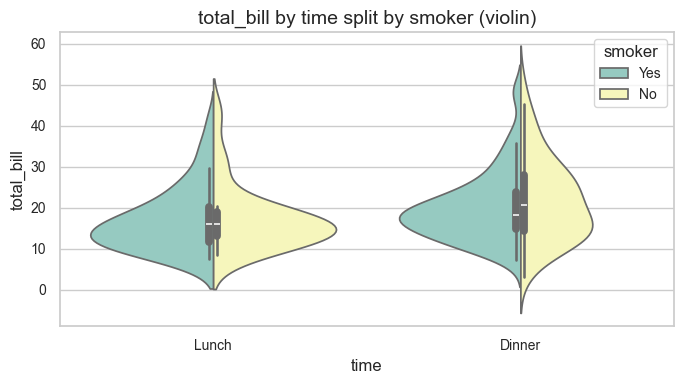

In [40]:
plt.figure(figsize=(7,4))
sns.violinplot(data=tips, x='time', y='total_bill', hue='smoker', split=True, palette='Set3')
plt.title('total_bill by time split by smoker (violin)')
plt.tight_layout()
plt.show()

### Ejercicio 4

1) Histograma de `total_bill` separado por `time`.
2) Boxplot de `total_bill` por `time` y `smoker`.
3) Violin de `tip` por `day` y `sex` (si te cuadra `split=True`, úsalo).


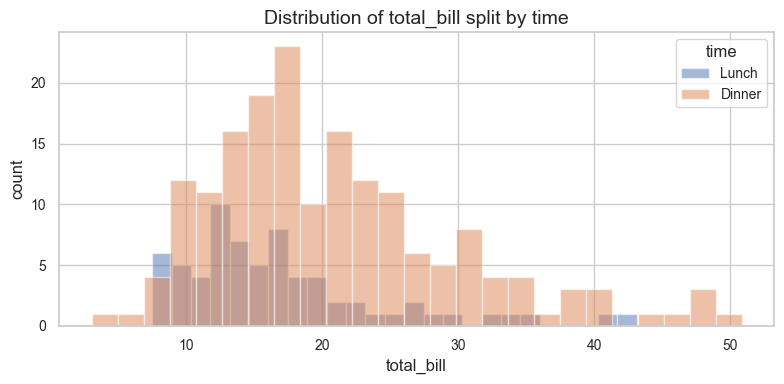

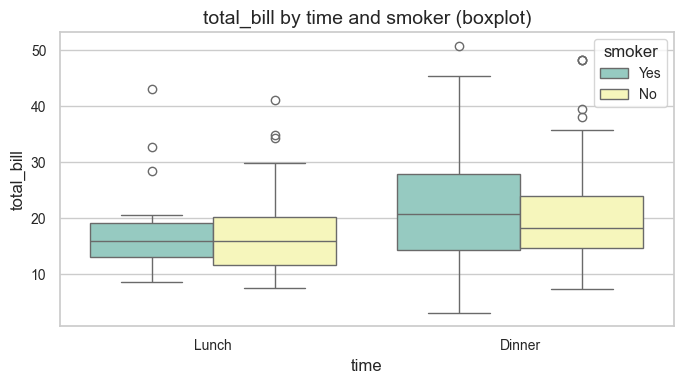

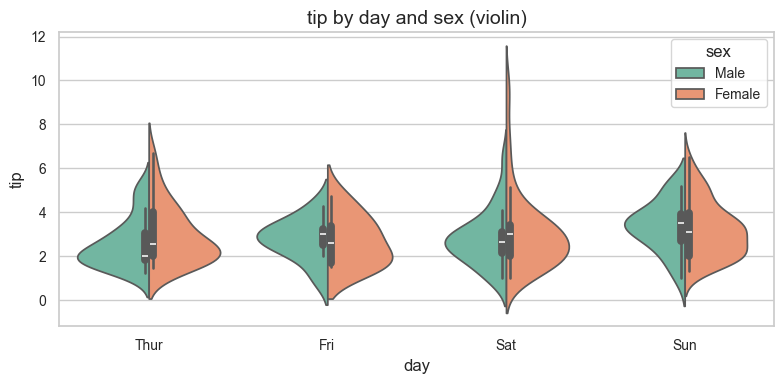

In [41]:
# Exercise 4
# 1) Histogram of total_bill split by time (matplotlib to avoid seaborn histplot incompatibilities)
fig, ax = plt.subplots(figsize=(8,4))
for t, sub in tips.groupby('time'):
    ax.hist(sub['total_bill'], bins=25, alpha=0.5, label=t, edgecolor='white')
ax.set_title('Distribution of total_bill split by time')
ax.set_xlabel('total_bill')
ax.set_ylabel('count')
ax.legend(title='time')
plt.tight_layout()
plt.show()

# 2) Boxplot of total_bill by time and smoker
plt.figure(figsize=(7,4))
sns.boxplot(data=tips, x='time', y='total_bill', hue='smoker', palette='Set3')
plt.title('total_bill by time and smoker (boxplot)')
plt.xlabel('time')
plt.ylabel('total_bill')
plt.tight_layout()
plt.show()

# 3) Violin of tip by day and sex
plt.figure(figsize=(8,4))
sns.violinplot(data=tips, x='day', y='tip', hue='sex', split=True, palette='Set2')
plt.title('tip by day and sex (violin)')
plt.xlabel('day')
plt.ylabel('tip')
plt.tight_layout()
plt.show()


---
## 7) Relación entre variables: scatter, transparencia, tamaños, regresión

Scatter responde a:
- ¿Sube Y cuando sube X?
- ¿Hay clusters?
- ¿Hay outliers?

Herramientas útiles:
- `alpha` (transparencia)
- `hue` (categoría)
- `size` (tercera variable)
- `sns.regplot` o `sns.lmplot` para tendencia

### Ejemplo 7.1 (scatter con alpha)
Relación `total_bill` vs `tip`.

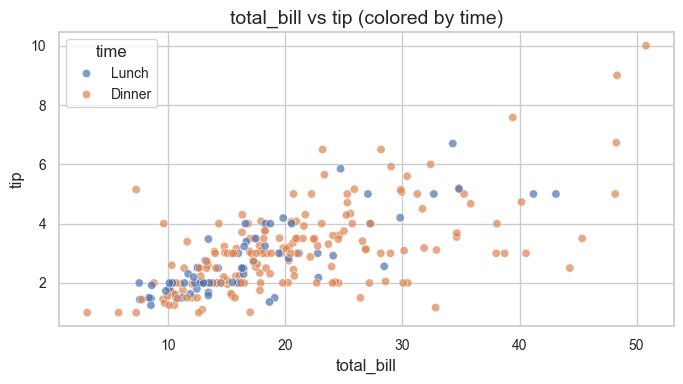

In [42]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', alpha=0.7)
plt.title('total_bill vs tip (colored by time)')
plt.tight_layout()
plt.show()

### Ejemplo 7.2 (regresión rápida)
Una recta de tendencia ayuda a contar la historia (sin entrar en modelado).

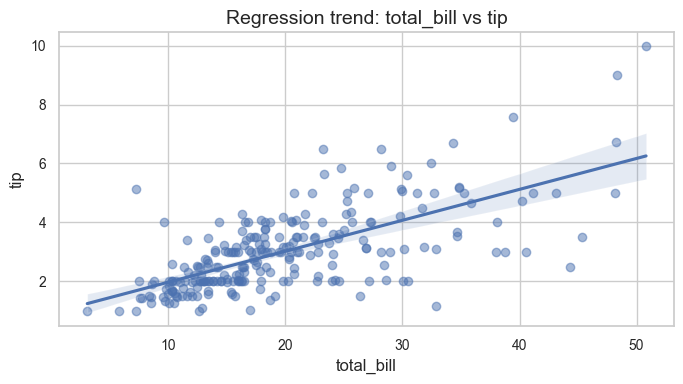

In [43]:
plt.figure(figsize=(7,4))
sns.regplot(data=tips, x='total_bill', y='tip', scatter_kws={'alpha': 0.5})
plt.title('Regression trend: total_bill vs tip')
plt.tight_layout()
plt.show()

### Ejercicio 5

1) Scatter de `total_bill` vs `tip` con `hue='smoker'` y `size='size'`.
2) Regplot para `total_bill` vs `tip` pero filtrando solo `time == 'Dinner'`.
3) Comenta: ¿la relación parece distinta en Lunch vs Dinner?

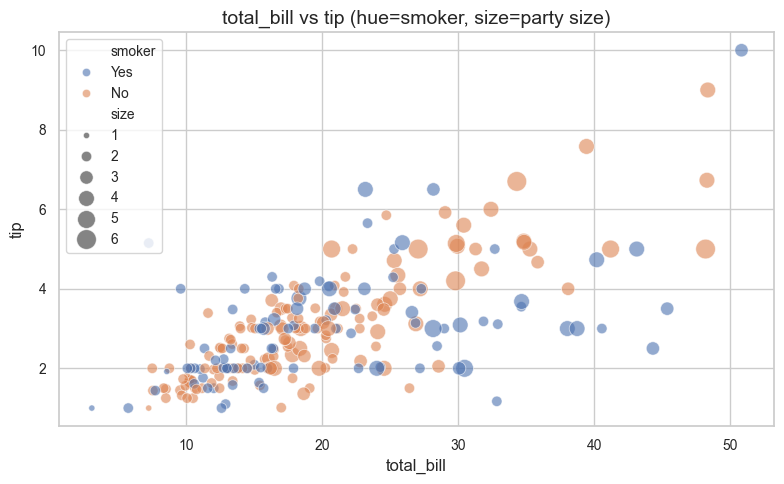

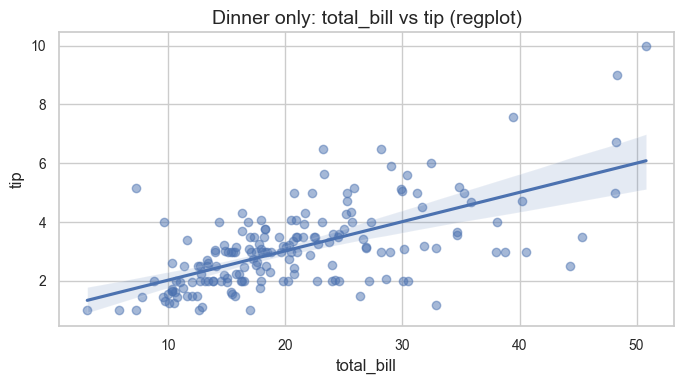

Correlation total_bill~tip: Lunch=0.81 vs Dinner=0.63. Both are positive; Dinner tends to show more spread at higher bills.


In [44]:
# Exercise 5
# 1) Scatter total_bill vs tip with hue=smoker and size=size
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    size='size',
    sizes=(20, 200),
    alpha=0.6
)
plt.title('total_bill vs tip (hue=smoker, size=party size)')
plt.tight_layout()
plt.show()

# 2) Regplot for Dinner only
dinner = tips[tips['time'] == 'Dinner']
plt.figure(figsize=(7,4))
sns.regplot(data=dinner, x='total_bill', y='tip', scatter_kws={'alpha': 0.5})
plt.title('Dinner only: total_bill vs tip (regplot)')
plt.tight_layout()
plt.show()

# 3) Quick comment (Lunch vs Dinner)
corr_lunch = tips[tips['time']=='Lunch'][['total_bill','tip']].corr().iloc[0,1]
corr_dinner = tips[tips['time']=='Dinner'][['total_bill','tip']].corr().iloc[0,1]
print(f"Correlation total_bill~tip: Lunch={corr_lunch:.2f} vs Dinner={corr_dinner:.2f}. "
      "Both are positive; Dinner tends to show more spread at higher bills.")


---
## 9) Series temporales: líneas, media móvil, estacionalidad (flights)

Aquí el objetivo es contar una historia:
- tendencia a largo plazo
- estacionalidad (patrón que se repite)
- variabilidad

Primero convertimos `year+month` a datetime mensual.

### Ejemplo 9.1 (serie mensual + rolling 12 meses)

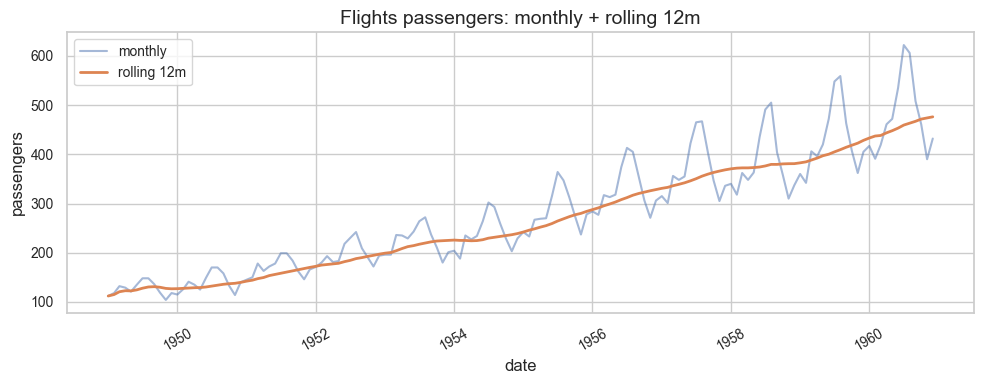

In [45]:
fl = flights.copy()

# Convert month name to month number safely
fl["month_num"] = pd.to_datetime(fl["month"], format="%b").dt.month

# Build datetime column
fl["date"] = pd.to_datetime(
    dict(year=fl["year"], month=fl["month_num"], day=1)
)

# Sort
fl = fl.sort_values("date")

# Rolling mean
fl["rolling_12"] = fl["passengers"].rolling(12, min_periods=1).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(fl["date"], fl["passengers"], alpha=0.5, label="monthly")
ax.plot(fl["date"], fl["rolling_12"], linewidth=2, label="rolling 12m")

ax.set_title("Flights passengers: monthly + rolling 12m")
ax.set_xlabel("date")
ax.set_ylabel("passengers")
ax.legend()

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Ejercicio 7

1) Crea `pct_change` mes a mes y dibuja un gráfico de líneas de ese crecimiento.
2) Dibuja la serie anual (agrega por año) y compárala con la mensual.
3) Comenta 2 cosas: tendencia y estacionalidad.

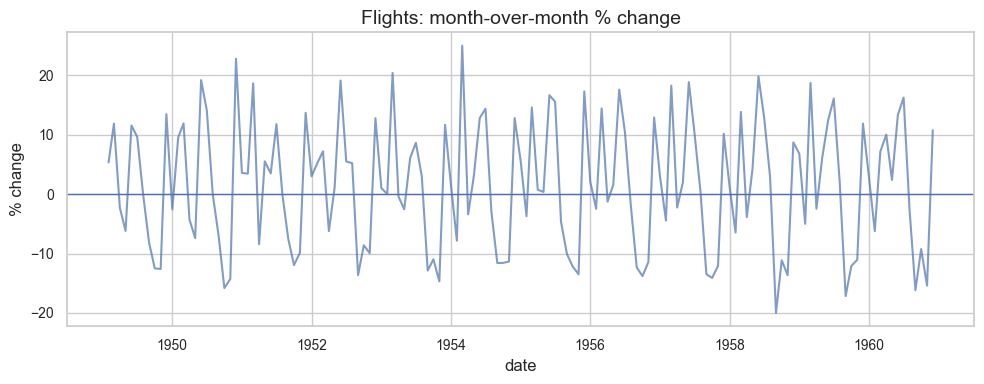

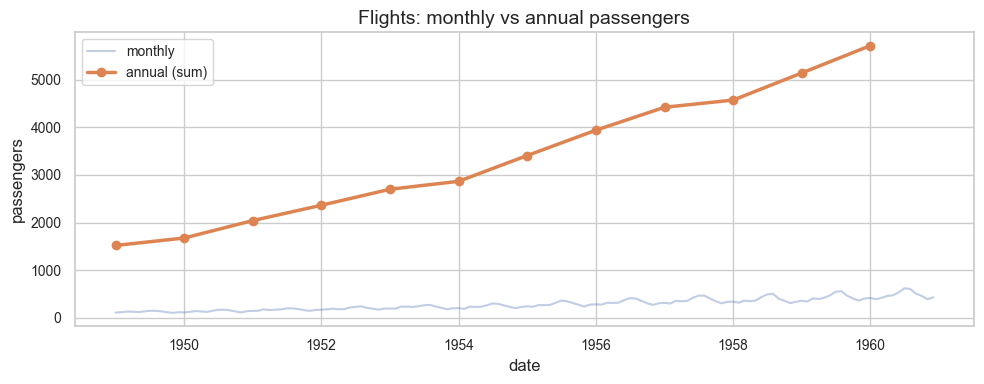

Tendencia: la serie crece de forma sostenida a lo largo de los años (la línea anual sube casi siempre).
Estacionalidad: se repite un patrón claro cada año (picos en verano y valles en invierno), que la agregación anual suaviza.


In [46]:
# Exercise 7
fl_ex = fl.copy()

# 1) MoM percent change
fl_ex['pct_change'] = fl_ex['passengers'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(fl_ex['date'], fl_ex['pct_change'], alpha=0.7)
ax.axhline(0, linewidth=1)
ax.set_title('Flights: month-over-month % change')
ax.set_xlabel('date')
ax.set_ylabel('% change')
plt.tight_layout()
plt.show()

# 2) Annual series (sum by year) vs monthly (sum by year-month already in passengers)
annual = fl_ex.groupby('year', as_index=False)['passengers'].sum()
annual['date'] = pd.to_datetime(dict(year=annual['year'], month=1, day=1))

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(fl_ex['date'], fl_ex['passengers'], alpha=0.35, label='monthly')
ax.plot(annual['date'], annual['passengers'], linewidth=2.5, marker='o', label='annual (sum)')
ax.set_title('Flights: monthly vs annual passengers')
ax.set_xlabel('date')
ax.set_ylabel('passengers')
ax.legend()
plt.tight_layout()
plt.show()

# 3) Comment (2 sentences)
print("Tendencia: la serie crece de forma sostenida a lo largo de los años (la línea anual sube casi siempre).")
print("Estacionalidad: se repite un patrón claro cada año (picos en verano y valles en invierno), que la agregación anual suaviza.")


---
## 10) Heatmaps: matriz mes×año (flights)

Heatmap útil para ver estacionalidad:
- filas: mes
- columnas: año
- color: pasajeros

Importante: un heatmap no es para "precisión"; es para patrones.

### Ejemplo 10.1 (heatmap base)

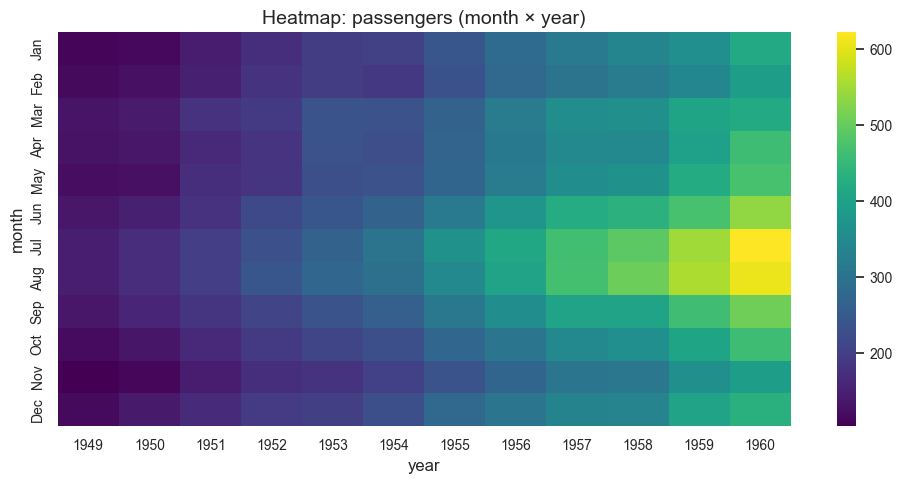

In [47]:
pivot = fl.pivot_table(index='month', columns='year', values='passengers', aggfunc='sum')

plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='viridis')
plt.title('Heatmap: passengers (month × year)')
plt.tight_layout()
plt.show()

### Ejemplo 10.2 (heatmap con anotaciones)
Ojo: `annot=True` puede saturar si la matriz es grande. Aquí es razonable.

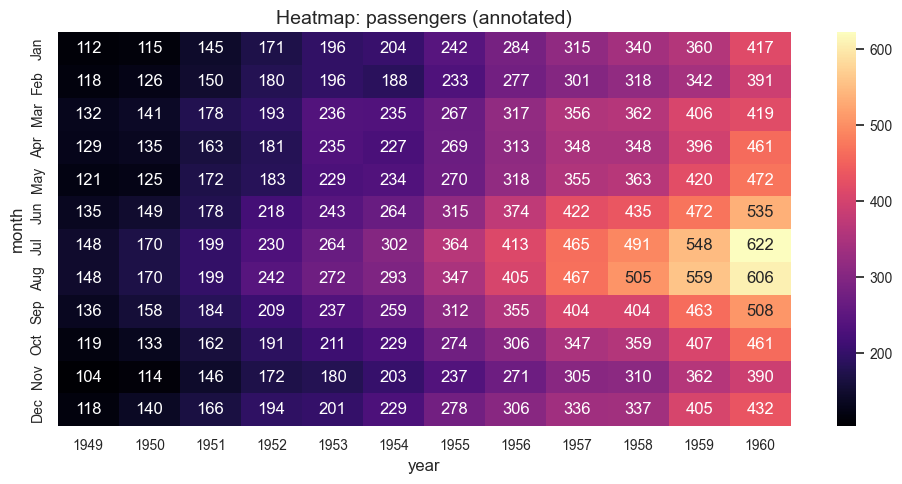

In [48]:
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='magma', annot=True, fmt='.0f')
plt.title('Heatmap: passengers (annotated)')
plt.tight_layout()
plt.show()

### Ejercicio 8

1) Cambia el colormap a otro y decide cuál comunica mejor.
2) Normaliza por año (por ejemplo, divide cada columna por su máximo) y repite el heatmap.
3) Escribe 2 frases: ¿qué se ve más claro tras normalizar?

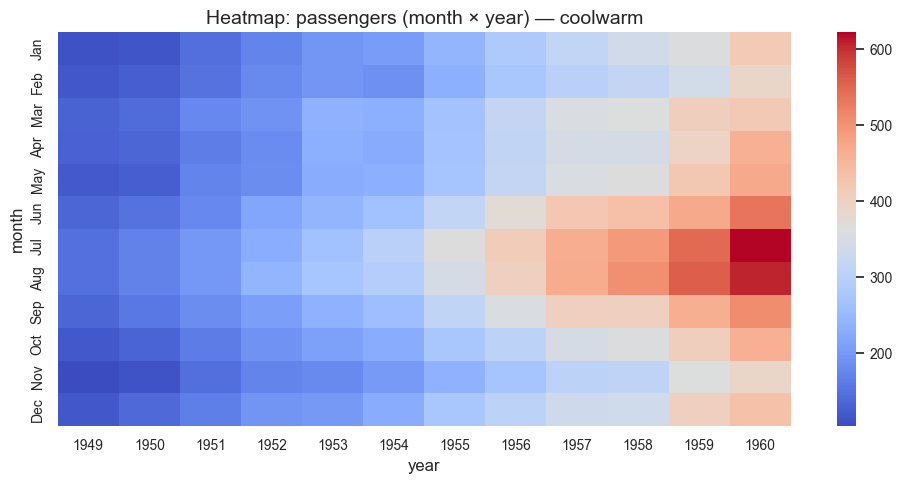

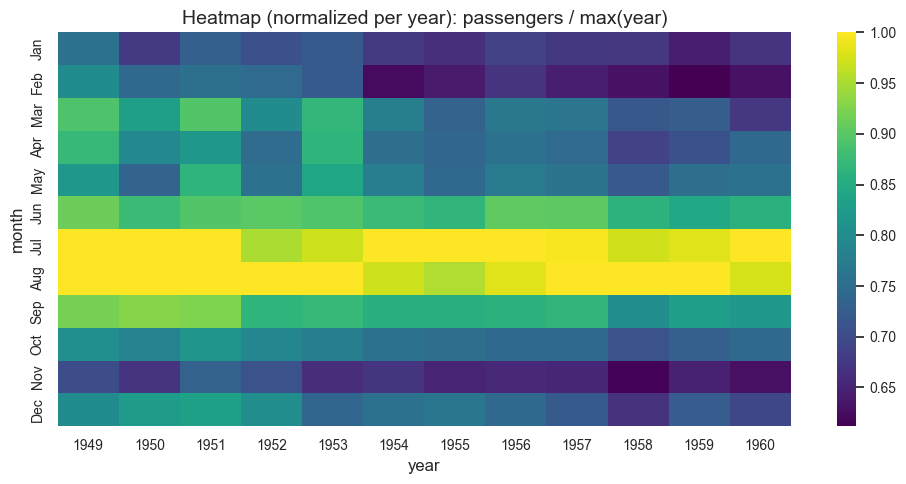

Tras normalizar, se ve mucho más claro el patrón estacional porque quitamos el efecto del crecimiento interanual.
Los meses de mayor demanda destacan por su posición dentro del año, no por el nivel absoluto de pasajeros.


In [49]:
# Exercise 8
# 1) Try a different colormap
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Heatmap: passengers (month × year) — coolwarm')
plt.tight_layout()
plt.show()

# 2) Normalize by year (each column scaled by its max)
pivot_norm = pivot.div(pivot.max(axis=0), axis=1)

plt.figure(figsize=(10,5))
sns.heatmap(pivot_norm, cmap='viridis')
plt.title('Heatmap (normalized per year): passengers / max(year)')
plt.tight_layout()
plt.show()

# 3) Two sentences
print("Tras normalizar, se ve mucho más claro el patrón estacional porque quitamos el efecto del crecimiento interanual.")
print("Los meses de mayor demanda destacan por su posición dentro del año, no por el nivel absoluto de pasajeros.")


---
## 11) Anotaciones, etiquetas y storytelling

Un gráfico útil suele tener:
- título que diga la conclusión o el tema
- ejes con unidades
- leyenda si aporta
- anotaciones SOLO cuando clarifican

Vamos a anotar el punto máximo en la serie de flights.

### Ejemplo 11.1 (anotar máximo)
Anotación simple con `ax.annotate`.

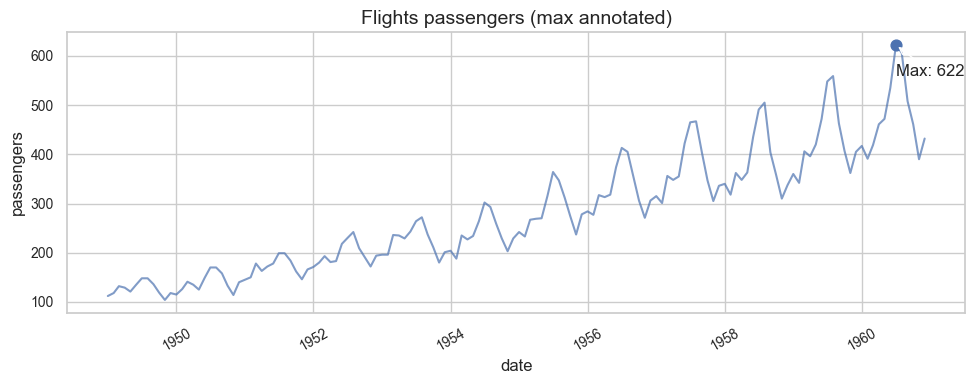

In [50]:
fl2 = fl.copy()
idx = fl2['passengers'].idxmax()
max_row = fl2.loc[idx]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(fl2['date'], fl2['passengers'], alpha=0.7)
ax.set_title('Flights passengers (max annotated)')
ax.set_xlabel('date')
ax.set_ylabel('passengers')

ax.scatter([max_row['date']], [max_row['passengers']], s=60)
ax.annotate(
    f"Max: {int(max_row['passengers'])}",
    xy=(max_row['date'], max_row['passengers']),
    xytext=(max_row['date'], max_row['passengers']*0.9),
    arrowprops={'arrowstyle': '->'}
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Ejercicio 9

1) Anota el **mínimo** en la serie.
2) Cambia el título para que sea un mensaje (ej: “Crecimiento sostenido con estacionalidad marcada”).
3) Ajusta posición del texto de la anotación para que no tape la línea.

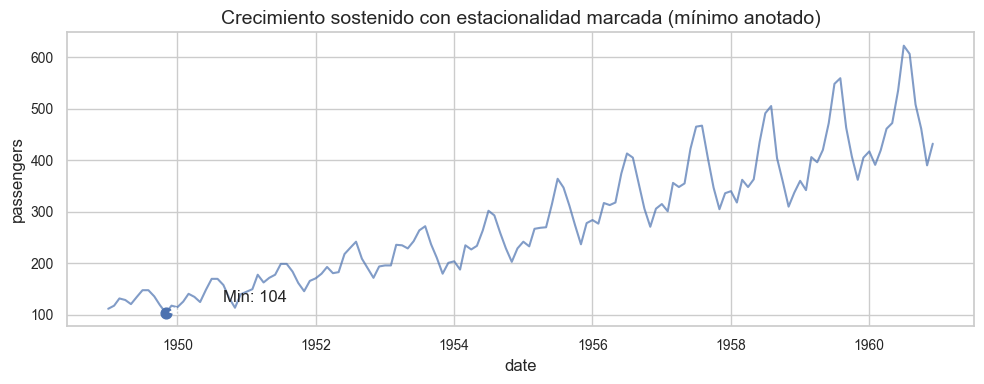

In [51]:
# Exercise 9
fl3 = fl.copy()
idx_min = fl3['passengers'].idxmin()
min_row = fl3.loc[idx_min]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(fl3['date'], fl3['passengers'], alpha=0.7)
ax.set_title('Crecimiento sostenido con estacionalidad marcada (mínimo anotado)')
ax.set_xlabel('date')
ax.set_ylabel('passengers')

ax.scatter([min_row['date']], [min_row['passengers']], s=60)

# Move label slightly right and up to avoid covering the line
ax.annotate(
    f"Min: {int(min_row['passengers'])}",
    xy=(min_row['date'], min_row['passengers']),
    xytext=(min_row['date'] + pd.DateOffset(months=10), min_row['passengers'] * 1.15),
    arrowprops=dict(arrowstyle='->', linewidth=1),
    ha='left',
    va='bottom'
)

plt.tight_layout()
plt.show()


---
## Apéndice opcional (si sobra tiempo o para casa)

Estas secciones no son necesarias para empezar, pero son muy útiles para proyectos.


### A1. Multivariable: pairplot y small multiples

Útil para un vistazo rápido cuando tienes varias variables numéricas y una categoría.


### Ejemplo 8.1 (pairplot)
Nota: puede tardar un poco dependiendo del entorno.

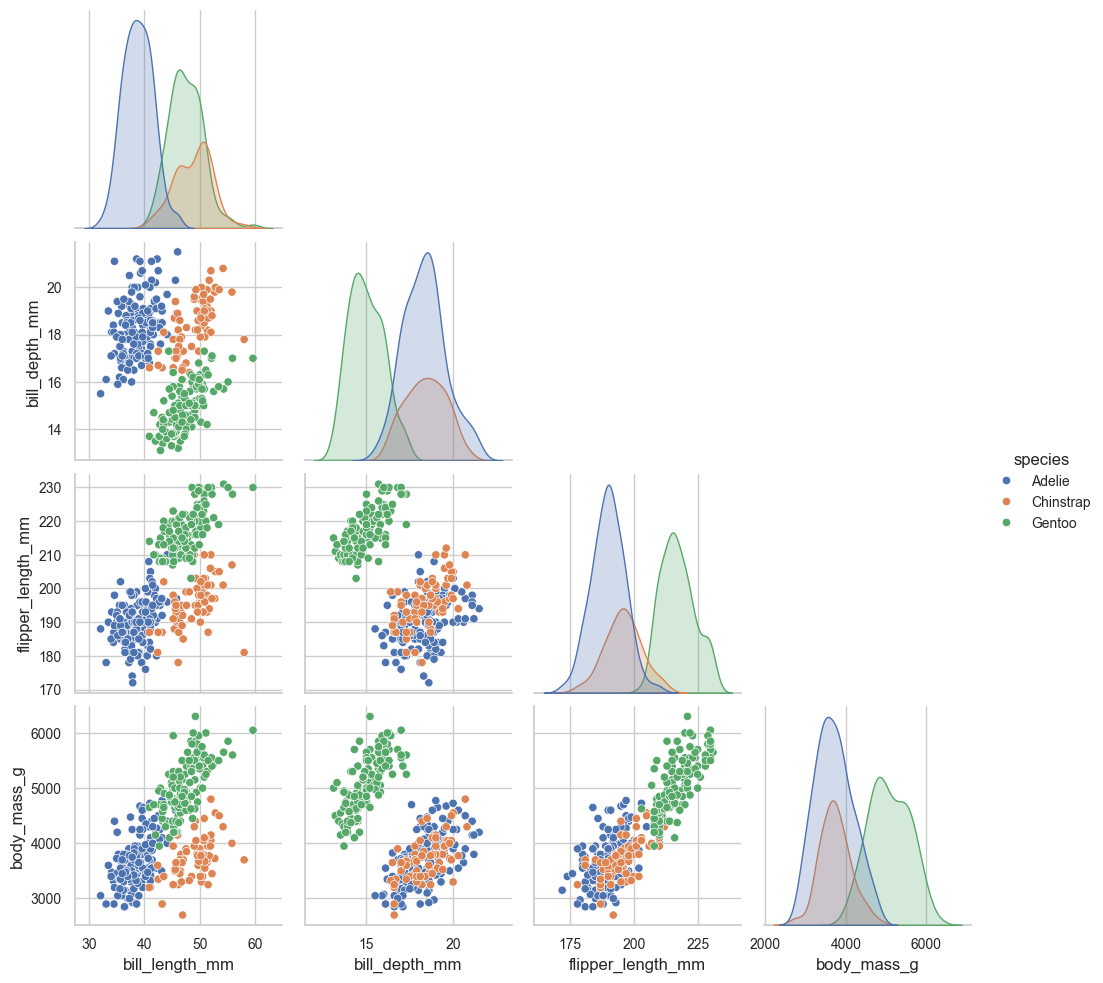

In [52]:
pp = penguins.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']).copy()
sns.pairplot(pp, hue='species', corner=True)
plt.show()

### Ejemplo 8.2 (small multiples con relplot)
Relación entre bill_length y body_mass separando por especie.

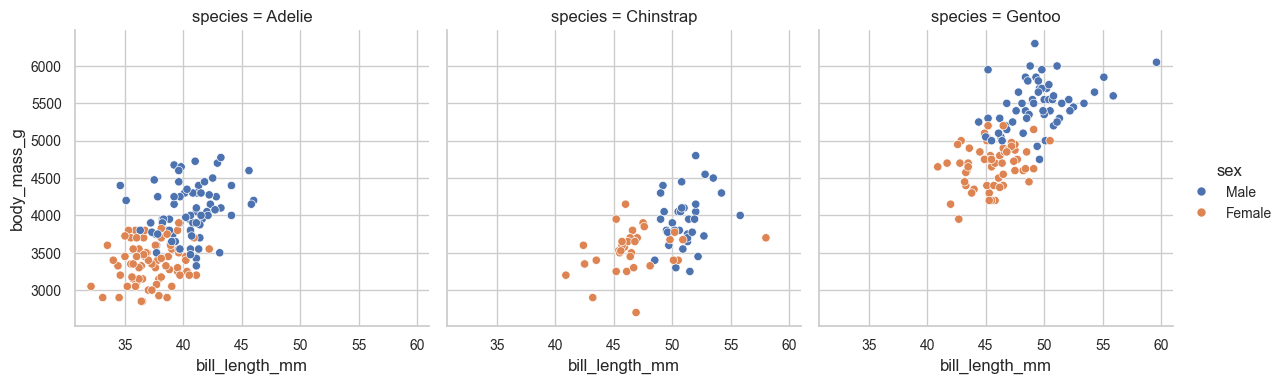

In [53]:
sns.relplot(
    data=pp,
    x='bill_length_mm',
    y='body_mass_g',
    col='species',
    hue='sex',
    kind='scatter',
    height=4,
    aspect=1
)
plt.show()

### Ejercicio 6

1) Haz un `pairplot` con `hue='sex'` (en penguins), usando solo 3 variables numéricas.
2) Haz un `relplot` separando por `island` (col) y coloreando por `species`.
3) Escribe 2 observaciones: un patrón y un posible outlier.

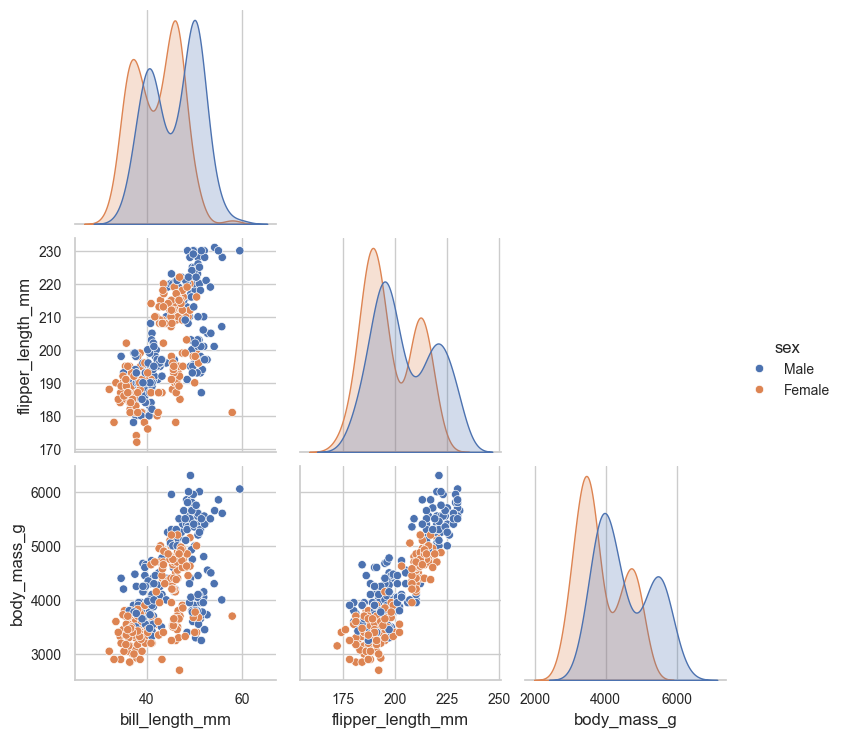

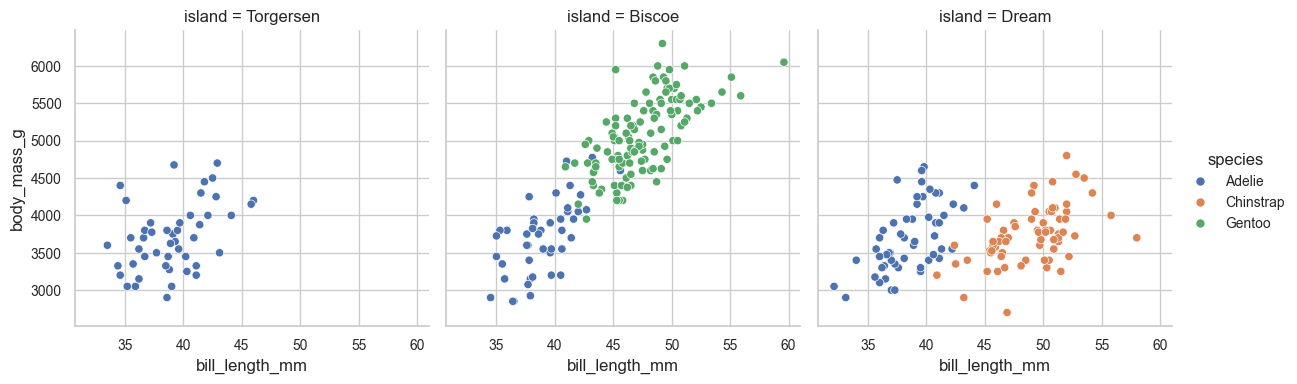

Patrón: en casi todas las islas, mayor bill_length_mm suele asociarse con mayor body_mass_g, y las especies tienden a agruparse.
Posible outlier: revisa puntos muy pesados con bill_length_mm pequeño (o viceversa); suelen ser pocos y destacan en algún panel.


In [54]:
# Exercise 6
pp2 = penguins.dropna(subset=['sex','bill_length_mm','flipper_length_mm','body_mass_g','species','island']).copy()

# 1) Pairplot (3 numeric vars) with hue='sex'
sns.pairplot(
    pp2[['bill_length_mm','flipper_length_mm','body_mass_g','sex']],
    hue='sex',
    corner=True
)
plt.show()

# 2) Relplot by island, color by species
sns.relplot(
    data=pp2,
    x='bill_length_mm',
    y='body_mass_g',
    col='island',
    hue='species',
    kind='scatter',
    height=4,
    aspect=1
)
plt.show()

# 3) Observations (2)
print("Patrón: en casi todas las islas, mayor bill_length_mm suele asociarse con mayor body_mass_g, y las especies tienden a agruparse.")
print("Posible outlier: revisa puntos muy pesados con bill_length_mm pequeño (o viceversa); suelen ser pocos y destacan en algún panel.")


### A2. Subplots y layout (comparar gráficos)

Cuando necesitas comparar varios gráficos en una sola figura.


### Ejemplo 12.1 (2 gráficos: hist + box)
Distribución de `total_bill` y comparación por `time`.

/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/1076867817.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='tip', ax=axes[1], palette='Set2')


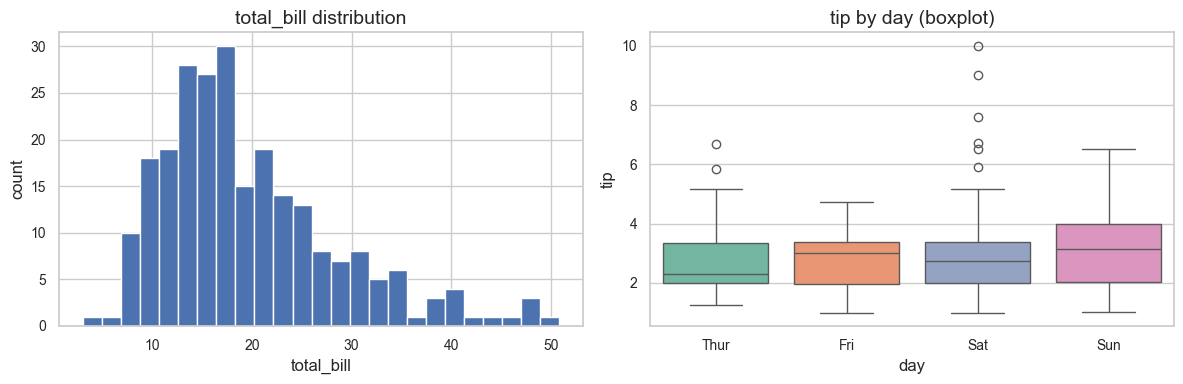

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# total_bill distribution (matplotlib hist)
axes[0].hist(tips['total_bill'], bins=25, edgecolor='white')
axes[0].set_title('total_bill distribution')
axes[0].set_xlabel('total_bill')
axes[0].set_ylabel('count')

# Boxplot tip by day (seaborn)
sns.boxplot(data=tips, x='day', y='tip', ax=axes[1], palette='Set2')
axes[1].set_title('tip by day (boxplot)')
axes[1].set_xlabel('day')
axes[1].set_ylabel('tip')

plt.tight_layout()
plt.show()


### Ejercicio 10

Crea una figura con 2×2 subplots:
- (0,0) Barplot tip media por day
- (0,1) Boxplot tip por time
- (1,0) Scatter total_bill vs tip (hue=smoker)
- (1,1) Histograma de total_bill

Ajusta `figsize` y usa `tight_layout()`.

/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/1468601355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='tip', ax=axes[0,0], palette='Set3')
/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/1468601355.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='time', y='tip', ax=axes[0,1], palette='Set2')


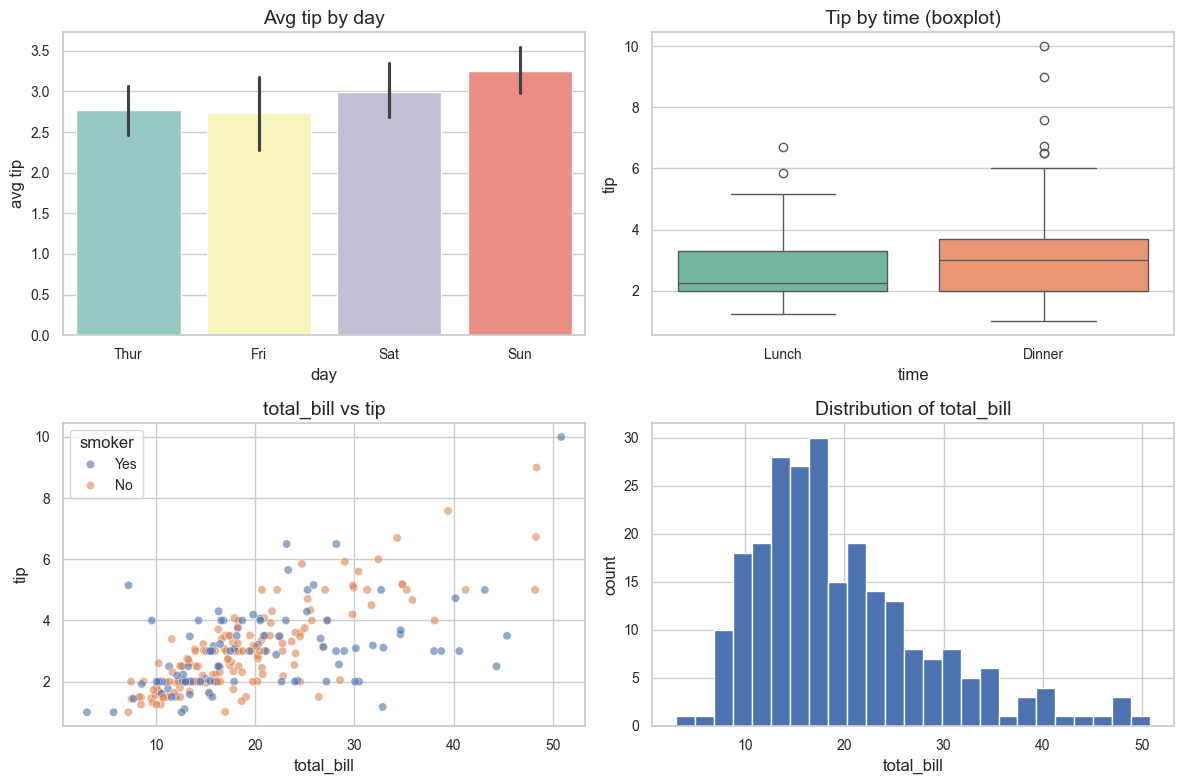

In [56]:
# Exercise 10
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (0,0) Barplot tip mean by day
sns.barplot(data=tips, x='day', y='tip', ax=axes[0,0], palette='Set3')
axes[0,0].set_title('Avg tip by day')
axes[0,0].set_xlabel('day')
axes[0,0].set_ylabel('avg tip')

# (0,1) Boxplot tip by time
sns.boxplot(data=tips, x='time', y='tip', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Tip by time (boxplot)')
axes[0,1].set_xlabel('time')
axes[0,1].set_ylabel('tip')

# (1,0) Scatter total_bill vs tip (hue=smoker)
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', ax=axes[1,0], alpha=0.6)
axes[1,0].set_title('total_bill vs tip')
axes[1,0].set_xlabel('total_bill')
axes[1,0].set_ylabel('tip')
axes[1,0].legend(title='smoker')

# (1,1) Histogram of total_bill
axes[1,1].hist(tips['total_bill'], bins=25, edgecolor='white')
axes[1,1].set_title('Distribution of total_bill')
axes[1,1].set_xlabel('total_bill')
axes[1,1].set_ylabel('count')

plt.tight_layout()
plt.show()


### A3. Exportar figuras (savefig)

Útil para entregar un proyecto: exportar gráficos a PNG/PDF.


### Ejemplo 13.1 (savefig)
Generamos una figura y la guardamos (comenta/descomenta si quieres guardar en tu entorno).

/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/4194952578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='tip', ax=ax, palette='Set3')


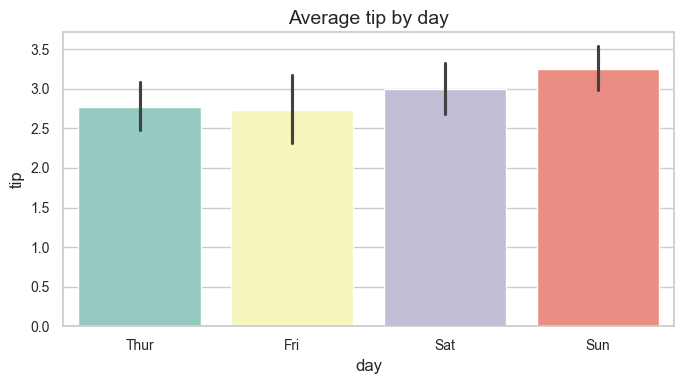

In [57]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=tips, x='day', y='tip', ax=ax, palette='Set3')
ax.set_title('Average tip by day')
plt.tight_layout()

# Uncomment to save
# fig.savefig('avg_tip_by_day.png', dpi=200, bbox_inches='tight')

plt.show()

### Ejercicio 11

1) Repite un gráfico que te haya gustado.
2) Guárdalo con nombre `my_chart.png`, `dpi=200` y `bbox_inches='tight'`.
3) Explica cuándo preferirías `png` vs `pdf`.

**PNG vs PDF (cuándo usar cada uno):**
- **PNG**: ideal para web, docs y chats; es raster (pierde calidad al ampliar) pero se ve igual en cualquier visor.
- **PDF**: ideal para informes y publicación; es vectorial (se escala sin perder nitidez) y mantiene tipografía/lineas perfectas.


/var/folders/5v/dc6514ld10d33dy0zgf23r6m0000gn/T/ipykernel_9072/3072805212.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='tip', ax=ax, palette='Set3')


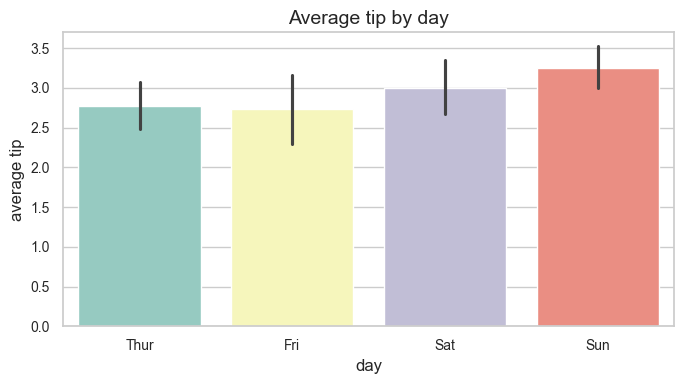

Saved: my_chart.png


In [58]:
# Exercise 11
# Repeat a chart and save it
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=tips, x='day', y='tip', ax=ax, palette='Set3')
ax.set_title('Average tip by day')
ax.set_xlabel('day')
ax.set_ylabel('average tip')
plt.tight_layout()

out_path = 'my_chart.png'
# fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {out_path}")


---
## 14) Mini-proyecto final (30–40 min)

Elige **uno** de estos datasets: `tips` o `penguins`.

Tarea:
1) Define 3 preguntas (una de comparación, una de distribución, una de relación).
2) Para cada pregunta, crea un gráfico.
3) Para cada gráfico escribe:
   - 1 frase: qué muestra
   - 1 frase: qué decisión o insight permite

Regla: no vale repetir el mismo tipo de gráfico 3 veces.

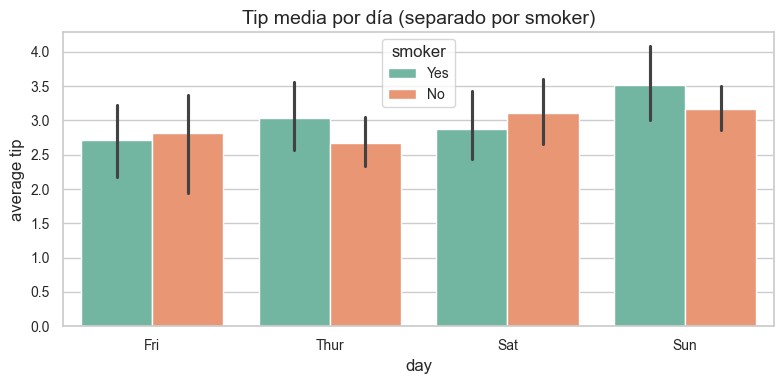

Muestra la propina media por día y si difiere entre fumadores y no fumadores.
Sirve para decidir si hay días/segmentos donde ajustar staffing o incentivos de servicio.



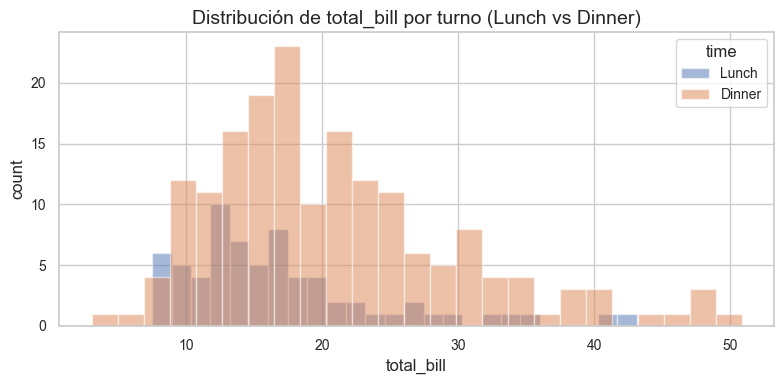

Muestra cómo cambia la distribución de cuentas entre lunch y dinner (nivel típico y colas).
Permite inferir en qué turno hay tickets más altos y planificar capacidad o promociones.



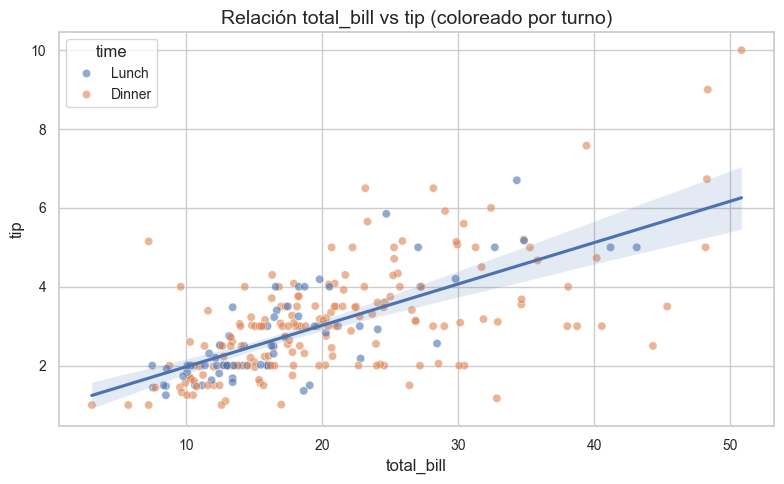

Muestra que a mayor cuenta suele aumentar la propina, y permite ver diferencias entre turnos.
Ayuda a estimar cómo impactan cambios de ticket medio en tips esperadas (y potencialmente en satisfacción/servicio).


In [59]:
# Mini-project (using tips)

# Pregunta 1 (comparación): ¿Qué día deja más propina media, y cambia si son fumadores?
order_days = (tips.groupby('day')['tip'].mean().sort_values()).index.tolist()
plt.figure(figsize=(8,4))
sns.barplot(data=tips, x='day', y='tip', hue='smoker', order=order_days, palette='Set2')
plt.title('Tip media por día (separado por smoker)')
plt.xlabel('day')
plt.ylabel('average tip')
plt.tight_layout()
plt.show()
print("Muestra la propina media por día y si difiere entre fumadores y no fumadores.")
print("Sirve para decidir si hay días/segmentos donde ajustar staffing o incentivos de servicio.\n")

# Pregunta 2 (distribución): ¿Cómo se distribuye la cuenta total entre Lunch y Dinner?
fig, ax = plt.subplots(figsize=(8,4))
for t, sub in tips.groupby('time'):
    ax.hist(sub['total_bill'], bins=25, alpha=0.5, label=t, edgecolor='white')
ax.set_title('Distribución de total_bill por turno (Lunch vs Dinner)')
ax.set_xlabel('total_bill')
ax.set_ylabel('count')
ax.legend(title='time')
plt.tight_layout()
plt.show()
print("Muestra cómo cambia la distribución de cuentas entre lunch y dinner (nivel típico y colas).")
print("Permite inferir en qué turno hay tickets más altos y planificar capacidad o promociones.\n")

# Pregunta 3 (relación): ¿Cómo se relaciona total_bill con tip y cambia por turno?
plt.figure(figsize=(8,5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', alpha=0.6)
sns.regplot(data=tips, x='total_bill', y='tip', scatter=False)
plt.title('Relación total_bill vs tip (coloreado por turno)')
plt.xlabel('total_bill')
plt.ylabel('tip')
plt.tight_layout()
plt.show()
print("Muestra que a mayor cuenta suele aumentar la propina, y permite ver diferencias entre turnos.")
print("Ayuda a estimar cómo impactan cambios de ticket medio en tips esperadas (y potencialmente en satisfacción/servicio).")


---
## Apéndice: Chuleta rápida (para recordar)

**Matplotlib (control):**
- `fig, ax = plt.subplots(figsize=(...))`
- `ax.plot / ax.bar / ax.scatter / ax.hist`
- `ax.set_title / set_xlabel / set_ylabel`
- `ax.legend()`
- `fig.savefig(..., dpi=..., bbox_inches='tight')`

**Seaborn (rápido + estadístico):**
- `sns.barplot`, `sns.boxplot`, `sns.violinplot`
- `sns.histplot`, `sns.scatterplot`, `sns.regplot`
- `hue=`, `size=`, `style=`, `palette=`
- `sns.heatmap(pivot)`

**Pregunta → gráfico:**
- comparar → bar
- distribución → hist/box/violin
- relación → scatter/reg
- tiempo → line
- matriz → heatmap